In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fire_area_matrix = np.load('/Users/isaaclee/Wildfire_Research/horse_recursive_validation_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/horse_fire_area_matrix.npz')
fire_area_growth_matrix = fire_area_matrix['arr_0']

print(fire_area_growth_matrix.shape)

(11, 100, 3)


In [7]:
area = np.sum(fire_area_growth_matrix[:, :, 2], axis=0)
#print(area)
print(np.mean(area))
print(np.std(area))
pred_area = np.mean(area)

condition_matrix = np.load("/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/horse_validation_case_data.npy")
print(condition_matrix.shape)
real_fire_area_growth = condition_matrix[:, 2]
print(real_fire_area_growth)

target_area = np.sum(real_fire_area_growth)
print(target_area)

7650.826939027656
433.71838627324684
(11, 27)
[  97.60662569  310.11725377  529.26883898  769.57882248  703.16925121
  551.04500073  568.80570002  504.86718256  809.57900611  931.89616995
 1154.59989502]
6930.533746521932


In [8]:
print(condition_matrix[:,5])

[0.5657145  0.59222334 0.62358504 0.62952884 0.57383515 0.5433273
 0.52313437 0.51652726 0.61115958 0.66184664 0.66636544]


In [9]:
pred_fire_area = fire_area_growth_matrix.copy()
mean_pred_fire_area = np.zeros(shape=(11))
std_at_timestep = np.zeros(shape=(11))
real_fire_area = real_fire_area_growth.copy()

for i in range(1,11):
    pred_fire_area[i, :, 2] = fire_area_growth_matrix[i, :, 2] + pred_fire_area[i-1, :, 2]
    real_fire_area[i] = real_fire_area_growth[i] + real_fire_area[i-1]

for i in range(0,11):
    mean_pred_fire_area[i] = np.mean(pred_fire_area[i, :, 2])
    std_at_timestep[i] = np.std(pred_fire_area[i, :, 2])

zeros = np.zeros((1, 100, 3))
pred_fire_area = np.concatenate((zeros, pred_fire_area), axis=0)
pred_fire_area = pred_fire_area[:, :, 2]
mean_pred_fire_area = np.insert(mean_pred_fire_area, 0, 0)
std_at_timestep = np.insert(std_at_timestep, 0, 0)
real_fire_area = np.insert(real_fire_area, 0, 0)

print(f"Shape of pred_fire_area matrix: {pred_fire_area.shape}")
print(f"Real fire area {real_fire_area}")
print(f"Mean predicted fire area {mean_pred_fire_area}")
print(f"Standard deviations {std_at_timestep}")

area_plus_1std  = mean_pred_fire_area + std_at_timestep
area_minus_1std = mean_pred_fire_area - std_at_timestep

Shape of pred_fire_area matrix: (12, 100)
Real fire area [   0.           97.60662569  407.72387946  936.99271844 1706.57154093
 2409.74079213 2960.78579286 3529.59149288 4034.45867544 4844.03768155
 5775.9338515  6930.53374652]
Mean predicted fire area [   0.          123.78677965  642.23435025 1570.87929702 2526.79301966
 3281.0912288  4037.87260123 4833.9257992  5670.87820777 6624.64283326
 7354.74808612 7650.82693903]
Standard deviations [  0.          63.02153961 332.6768998  646.07100631 755.47434513
 724.39050065 760.60476031 684.72256121 535.82085649 523.11106313
 487.01588381 433.71838627]


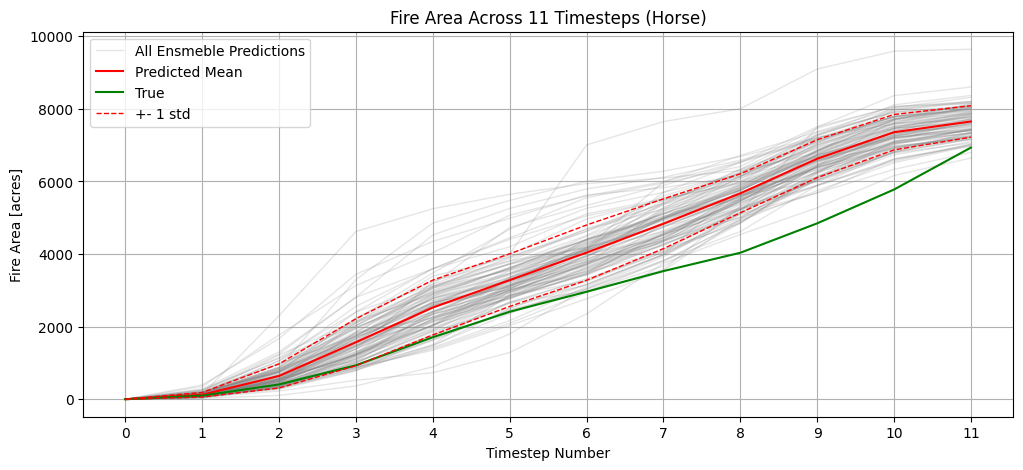

In [10]:
plt.figure(figsize=(12,5))
plt.title('Fire Area Across 11 Timesteps (Horse)')
plt.xlabel('Timestep Number')
plt.xticks(range(0, 12))
plt.ylabel('Fire Area [acres]')
plt.grid(True)
for i in range(0,100):
    if i == 0:
        plt.plot(pred_fire_area[:, i], color='gray', alpha=0.2, linewidth=1, label='All Ensmeble Predictions')
    else:
        plt.plot(pred_fire_area[:, i], alpha=0.2, linewidth=1, color='gray')
plt.plot(mean_pred_fire_area, color='red', label='Predicted Mean')
plt.plot(real_fire_area, color='green', label='True')
plt.plot(area_plus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed', label='+- 1 std')
plt.plot(area_minus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed')
plt.legend()
plt.show()